# Online Discussion of #OscarSoWhite

## Twitter Analysis

In [12]:
import ast
from IPython.display import display, clear_output
import json
from ipywidgets import widgets, VBox, HBox, Button, Label, Output
import pandas as pd
import pyktok as pyk
import random
from openai import OpenAI
import seaborn as sns
import matplotlib.pyplot as plt

from dotenv import load_dotenv

_ = load_dotenv()

In [13]:
client = OpenAI()

In [14]:
df = pd.read_csv('oscarssowhite_tweets_2015-2022.csv')

sample_df = df.sample(n=100, random_state=42).reset_index(drop=True)
text_col = 'text'

for col in ['coder1_concept1', 'coder1_concept2', 'coder2_concept1', 'coder2_concept2']:
    sample_df[col] = None

In [15]:
concept1 = "Code 1 if the tweet supports or amplifies the #OscarsSoWhite movement, criticizes the lack of racial diversity at the Oscars, or expresses solidarity with underrepresented groups. Code 0 for everything else."

concept2 = "Code 1 if the tweet opposes, criticizes, or dismisses the #OscarsSoWhite movement, defends the Academy's choices, does not support racial diversity, or ridicules those calling out the lack of diversity. Code 0 for everything else."

In [17]:
main_out = Output()
coder1_out = Output()

def code_entries(coder_label, concept1_col, concept2_col, container_out):
    index = 0
    text_label = Label(value=sample_df.loc[index, text_col])
    concept1_toggle = widgets.ToggleButtons(options=[0, 1], description='Concept 1:')
    concept2_toggle = widgets.ToggleButtons(options=[0, 1], description='Concept 2:')
    next_button = Button(description='Next →', button_style='success')
    progress = Label(value=f"{coder_label}: {index + 1}/{len(sample_df)}")

    def next_entry(_):
        nonlocal index
        sample_df.loc[index, concept1_col] = concept1_toggle.value
        sample_df.loc[index, concept2_col] = concept2_toggle.value
        index += 1
        if index < len(sample_df):
            text_label.value = sample_df.loc[index, text_col]
            concept1_toggle.value = None
            concept2_toggle.value = None
            progress.value = f"{coder_label}: {index + 1}/{len(sample_df)}"
        else:
            container_out.clear_output()
            with container_out:
                display(Label(value=f"{coder_label} has finished coding! ✅"))
            with main_out:
                print("✅ Coder finished. Saving data...")
                sample_df.to_csv('coded_data.csv', index=False)
                print("💾 Coded data saved to coded_data.csv")

    next_button.on_click(next_entry)
    with container_out:
        container_out.clear_output()
        display(VBox([progress, text_label, concept1_toggle, concept2_toggle, next_button]))

# ---- Workflow ----
print(f"Support: {concept1}")
print(f"Anti: {concept2}\n")
print("=== Coder: Please start coding ===")
code_entries("Coder", "coder1_concept1", "coder1_concept2", coder1_out)
display(coder1_out, main_out)

Support: Code 1 if the tweet supports or amplifies the #OscarsSoWhite movement, criticizes the lack of racial diversity at the Oscars, or expresses solidarity with underrepresented groups. Code 0 for everything else.
Anti: Code 1 if the tweet opposes, criticizes, or dismisses the #OscarsSoWhite movement, defends the Academy's choices, does not support racial diversity, or ridicules those calling out the lack of diversity. Code 0 for everything else.

=== Coder: Please start coding ===


Output()

Output()

In [7]:
sample_df.to_csv('coded_data.csv', index=False)
print("💾 Coded data saved to coded_data.csv")

💾 Coded data saved to coded_data.csv


In [8]:
LLM_prompt = '''You are a social-science research assistant helping code tweets for a content analysis study on #OscarsSoWhite.

For Concept 1:
Code "1" if the tweet supports or amplifies the #OscarsSoWhite movement, criticises the lack of racial diversity at the Oscars, expresses solidarity with underrepresented groups, or praises diverse nominees/films. Code "0" for everything else.

For Concept 2:
Code "1" if the tweet opposes, mocks, or dismisses the #OscarsSoWhite movement, defends the Academy's choices as merit-based, or ridicules those calling out the lack of diversity. Code "0" for everything else.

Important Clarification Rules for both concepts:
A comment can receive two zeros if it supports neither side.
If a comment is ambiguous, vague, or does not explicitly take a stance, code both concepts as 0.
Retweets (starting with "RT @") should be coded the same as original tweets.
A tweet may NOT be coded 1 for both concepts simultaneously.
Do not infer meaning beyond what is written. When in doubt, code 0.
'''

In [9]:
batch_size = 10

def ai_code_batch(text_list):
    texts_formatted = "\n".join([f"{i+1}. {t}" for i, t in enumerate(text_list)])
    
    prompt = f"""
        {LLM_prompt}
        
        You will receive {len(text_list)} texts.
        
        Return ONLY valid JSON — a list of {len(text_list)} dictionaries like this:
        
        [
          {{"concept1": 1, "concept2": 0}},
          ...
        ]
        
        No explanations, no comments, no extra text — only the JSON array.
        
        Texts:
        {texts_formatted}
        """

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )

    try:
        output_text = response.choices[0].message.content.strip()
        batch_json = json.loads(output_text)
        return batch_json  
    except Exception as e:
        try:
            print("Trying to parse")
            s = output_text.replace("```", "").replace("json", "").replace("\n", "").strip()
            lst = json.loads(s)
            print("✅ Parsed successfully.")
            return lst
        except Exception as e:
            print("⚠️ Parsing error:", e)
            return [{"concept1": None, "concept2": None} for _ in text_list]

In [10]:
sample_df = pd.read_csv('coded_data.csv')

text_col = 'text'

sample_ai_concept1, sample_ai_concept2 = [], []

for start in range(0, len(sample_df), batch_size):
    print(f"Beginning coding round {(start//10) + 1}")
    end = start + batch_size
    sample_batch_texts = sample_df[text_col].iloc[start:end].tolist()
    sample_batch_results = ai_code_batch(sample_batch_texts)

    for r in sample_batch_results:
        sample_ai_concept1.append(r.get("concept1"))
        sample_ai_concept2.append(r.get("concept2"))

sample_df["ai_concept1"] = sample_ai_concept1
sample_df["ai_concept2"] = sample_ai_concept2

sample_df.to_csv("ai_coded_data.csv", index=False)
print("✅ Combined human + AI coded data saved to ai_coded_data.csv")

Beginning coding round 1


RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

### Analysis from Sample Size of 100 Tweets

In [18]:
sample_coded_data = pd.read_csv('coded_data.csv')

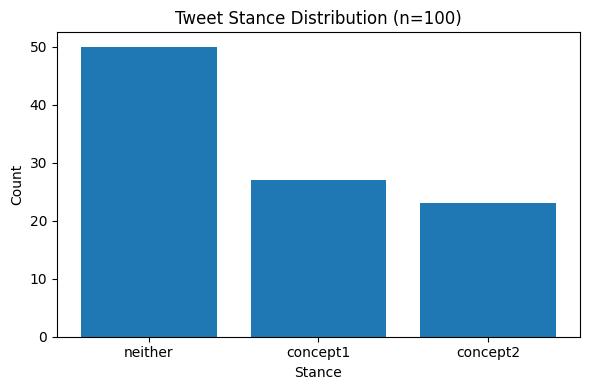

In [19]:
def collapse(x):
    if x.coder1_concept1 == 1:
        return "concept1"
    elif x.coder1_concept2 == 1:
        return "concept2"
    else:
        return "neither"

sample_coded_data['collapsed_codes'] = sample_coded_data.apply(collapse, axis=1)

counts = sample_coded_data['collapsed_codes'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values)
plt.title("Tweet Stance Distribution (n=100)")
plt.xlabel("Stance")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

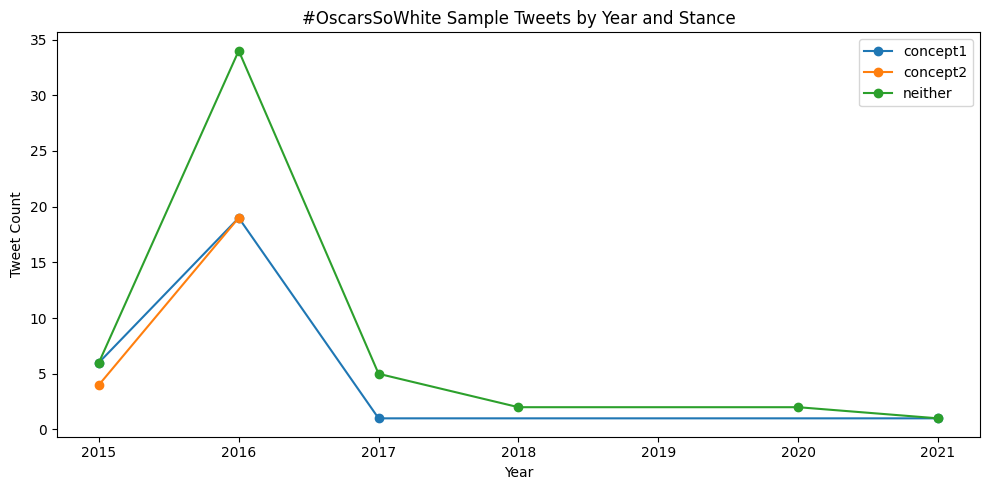

In [25]:
time_series = (
   sample_coded_data.groupby(['year', 'collapsed_codes'])
    .size()
    .reset_index(name='count')
)

fig, ax = plt.subplots(figsize=(10, 5))
for stance, grp in time_series.groupby('collapsed_codes'):
    ax.plot(grp['year'], grp['count'], marker='o', label=stance)

ax.set_title("#OscarsSoWhite Sample Tweets by Year and Stance")
ax.set_xlabel("Year")
ax.set_ylabel("Tweet Count")
ax.legend()
plt.tight_layout()
plt.show()